# Phase 5 Geospatial Analysis

This notebook turns the `2025-2026` NYC 311 analysis into a spatial story. It combines point-level complaint coordinates, Phase 4 NLP subtype labels, Census ZIP reference data, and community board rollups to show where complaint pressure is concentrated, where burden looks highest relative to resident population, and which zones stay hot over time.


In [1]:
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

from geo import (
    COMMUNITY_BOARD_METRICS_PATH,
    COMMUNITY_BOARD_MONTHLY_PATH,
    GRID_MONTHLY_PATH,
    GRID_PERSISTENCE_GEOJSON_PATH,
    GRID_PERSISTENCE_PATH,
    ZCTA_METRICS_PATH,
    build_geo_outputs,
    sample_geocoded_rows,
    summarize_hotspot_grids,
    top_complaint_types,
    top_modeled_subtypes,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore', message='.*tight_layout.*')

OUTPUTS = [
    ZCTA_METRICS_PATH,
    COMMUNITY_BOARD_METRICS_PATH,
    COMMUNITY_BOARD_MONTHLY_PATH,
    GRID_MONTHLY_PATH,
    GRID_PERSISTENCE_PATH,
    GRID_PERSISTENCE_GEOJSON_PATH,
]

BOROUGH_COLORS = {
    'BRONX': '#e15759',
    'BROOKLYN': '#4e79a7',
    'MANHATTAN': '#59a14f',
    'QUEENS': '#f28e2b',
    'STATEN ISLAND': '#b07aa1',
}

def format_int(value, _):
    return f'{int(value):,}'


def style_axis(ax, title, xlabel='', ylabel=''):
    ax.set_title(title, loc='left', fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def annotate_barh(ax, fmt='{:.0f}', offset=0.01):
    x_max = ax.get_xlim()[1] if ax.get_xlim()[1] else 1
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width + x_max * offset, y, fmt.format(width), va='center', ha='left', fontsize=9)


def draw_kpi_row(items, ncols=4, figsize=(16, 3.4)):
    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    for ax, item in zip(axes, items):
        ax.axis('off')
        ax.text(0.02, 0.72, item['label'], fontsize=10, color='#666666', transform=ax.transAxes)
        ax.text(0.02, 0.38, item['value'], fontsize=24, fontweight='bold', color=item.get('color', '#222222'), transform=ax.transAxes)
        ax.text(0.02, 0.12, item['note'], fontsize=9, color='#777777', transform=ax.transAxes)
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='#dddddd', linewidth=1, transform=ax.transAxes, clip_on=False))
    plt.tight_layout()
    plt.show()


def plot_hexbin(ax, sample, title, gridsize=90):
    hb = ax.hexbin(sample['longitude'], sample['latitude'], gridsize=gridsize, cmap='magma', mincnt=1, linewidths=0)
    style_axis(ax, title, 'Longitude', 'Latitude')
    return hb


## Build Analysis Outputs

This cell rebuilds the reusable Phase 5 outputs and loads the analysis frame used below.


In [2]:
df, zcta_metrics, community_board_metrics, community_board_monthly, monthly_grid, grid_persistence = build_geo_outputs()

print(f'Rows in geospatial analysis frame: {len(df):,}')
print(f'ZIP metrics rows: {len(zcta_metrics):,}')
print(f'Community board metrics rows: {len(community_board_metrics):,}')
print(f'Community board monthly rows: {len(community_board_monthly):,}')
print(f'Monthly grid rows: {len(monthly_grid):,}')
print(f'Persistent grid cells: {len(grid_persistence):,}')
for output in OUTPUTS:
    print(f'Wrote: {output}')


Rows in geospatial analysis frame: 4,767,760
ZIP metrics rows: 210
Community board metrics rows: 77
Community board monthly rows: 1,231
Monthly grid rows: 14,543
Persistent grid cells: 965
Wrote: /Users/jahankazimi/PycharmProjects/311Analyzer/data/analytics/requests_2025_2026_zcta_metrics.parquet
Wrote: /Users/jahankazimi/PycharmProjects/311Analyzer/data/analytics/requests_2025_2026_community_board_metrics.parquet
Wrote: /Users/jahankazimi/PycharmProjects/311Analyzer/data/analytics/requests_2025_2026_community_board_monthly.parquet
Wrote: /Users/jahankazimi/PycharmProjects/311Analyzer/data/analytics/requests_2025_2026_grid_monthly.parquet
Wrote: /Users/jahankazimi/PycharmProjects/311Analyzer/data/analytics/requests_2025_2026_grid_persistence.parquet
Wrote: /Users/jahankazimi/PycharmProjects/311Analyzer/data/analytics/requests_2025_2026_grid_persistence.geojson


## Executive Summary

These cards show the scale of the spatial layer and how much of the Phase 4 taxonomy carries into geography.


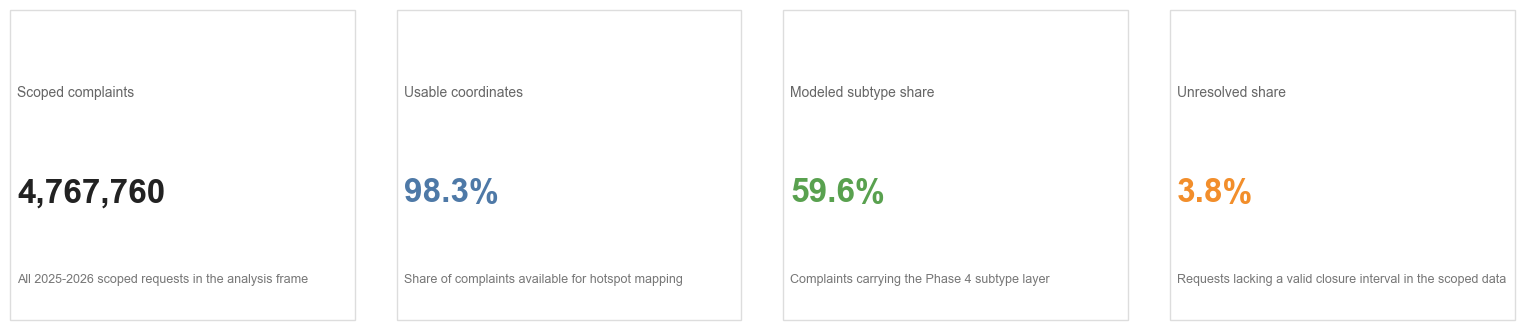

In [3]:
kpis = [
    {
        'label': 'Scoped complaints',
        'value': f"{len(df):,}",
        'note': 'All 2025-2026 scoped requests in the analysis frame',
        'color': '#222222',
    },
    {
        'label': 'Usable coordinates',
        'value': f"{df['valid_coordinate_flag'].mean():.1%}",
        'note': 'Share of complaints available for hotspot mapping',
        'color': '#4e79a7',
    },
    {
        'label': 'Modeled subtype share',
        'value': f"{df['subtype_modeled_flag'].mean():.1%}",
        'note': 'Complaints carrying the Phase 4 subtype layer',
        'color': '#59a14f',
    },
    {
        'label': 'Unresolved share',
        'value': f"{df['unresolved_flag'].mean():.1%}",
        'note': 'Requests lacking a valid closure interval in the scoped data',
        'color': '#f28e2b',
    },
]
draw_kpi_row(kpis)


In [4]:
qa_summary = pd.Series({
    'rows': len(df),
    'valid_nyc_coordinates': int(df['valid_coordinate_flag'].sum()),
    'valid_coordinate_rate': df['valid_coordinate_flag'].mean(),
    'zip_present_rate': df['incident_zip_clean'].notna().mean(),
    'community_board_present_rate': df['community_board'].notna().mean(),
    'modeled_subtype_rate': df['subtype_modeled_flag'].mean(),
    'mismatch_flag_rate': df['potential_label_mismatch_flag'].mean(),
    'unresolved_rate': df['unresolved_flag'].mean(),
}).to_frame('value')
qa_summary


,value
rows,4.767760e+06
valid_nyc_coordinates,4.685669e+06
valid_coordinate_rate,9.827821e-01
zip_present_rate,9.913821e-01
community_board_present_rate,1.000000e+00
modeled_subtype_rate,5.961032e-01
mismatch_flag_rate,2.097421e-07
unresolved_rate,3.848012e-02


## Geographic Coverage By Borough

This is a quick coverage check before leaning on the hotspot and board comparisons.


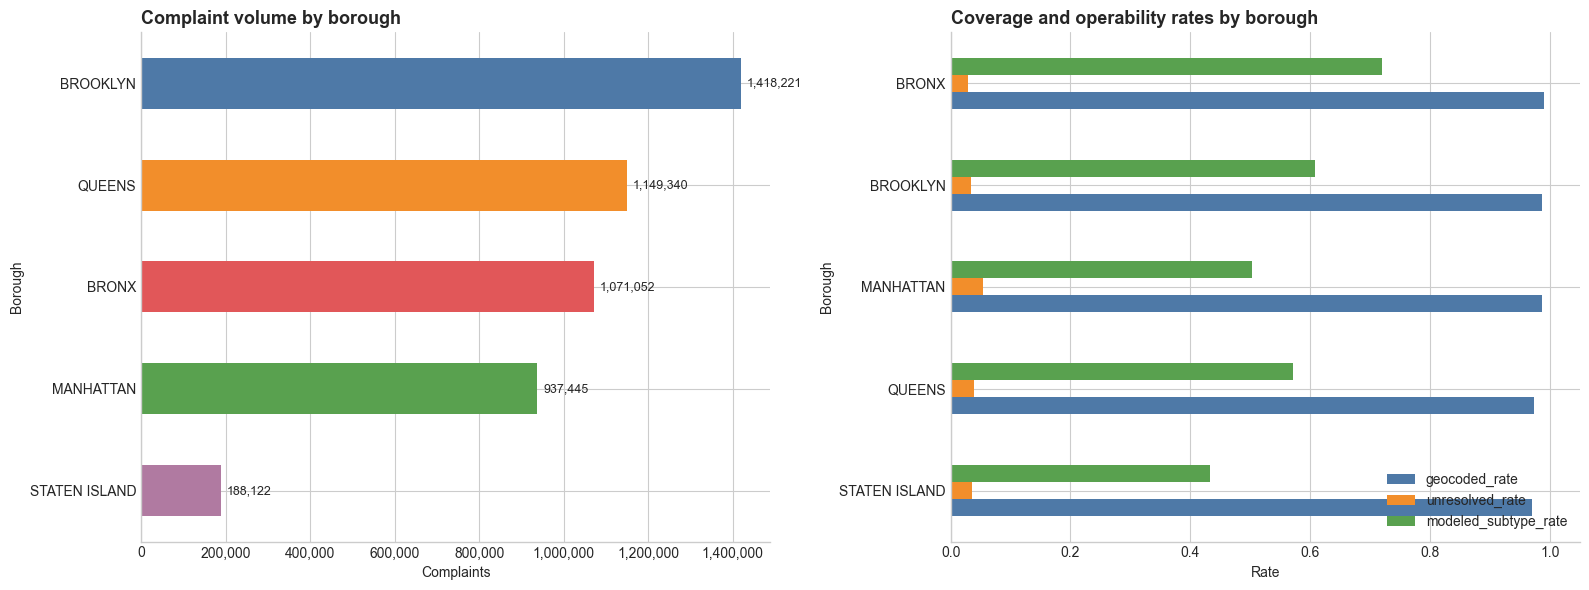

,complaints,geocoded_rate,unresolved_rate,modeled_subtype_rate
borough,,,,
BROOKLYN,1418221,0.986983,0.034741,0.607894
QUEENS,1149340,0.972623,0.039198,0.571098
BRONX,1071052,0.989634,0.029809,0.719569
MANHATTAN,937445,0.986954,0.053351,0.502658
STATEN ISLAND,188122,0.970689,0.035073,0.432007


In [5]:
borough_quality = (
    df.groupby('borough', observed=True)
    .agg(
        complaints=('unique_key', 'size'),
        geocoded_rate=('valid_coordinate_flag', 'mean'),
        unresolved_rate=('unresolved_flag', 'mean'),
        modeled_subtype_rate=('subtype_modeled_flag', 'mean'),
    )
    .sort_values('complaints', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [BOROUGH_COLORS.get(b, '#999999') for b in borough_quality.index]

borough_quality['complaints'].sort_values().plot(kind='barh', ax=axes[0], color=colors[::-1], legend=False)
style_axis(axes[0], 'Complaint volume by borough', 'Complaints', 'Borough')
axes[0].xaxis.set_major_formatter(FuncFormatter(format_int))
annotate_barh(axes[0], fmt='{:,.0f}')

rate_df = borough_quality[['geocoded_rate', 'unresolved_rate', 'modeled_subtype_rate']].sort_values('geocoded_rate')
rate_df.plot(kind='barh', ax=axes[1], color=['#4e79a7', '#f28e2b', '#59a14f'])
style_axis(axes[1], 'Coverage and operability rates by borough', 'Rate', 'Borough')
axes[1].set_xlim(0, 1.05)
plt.tight_layout()
plt.show()
borough_quality


## Citywide Hotspot Density

These maps use point coordinates directly: first the citywide pattern, then the leading complaint families, then the top modeled subtypes.


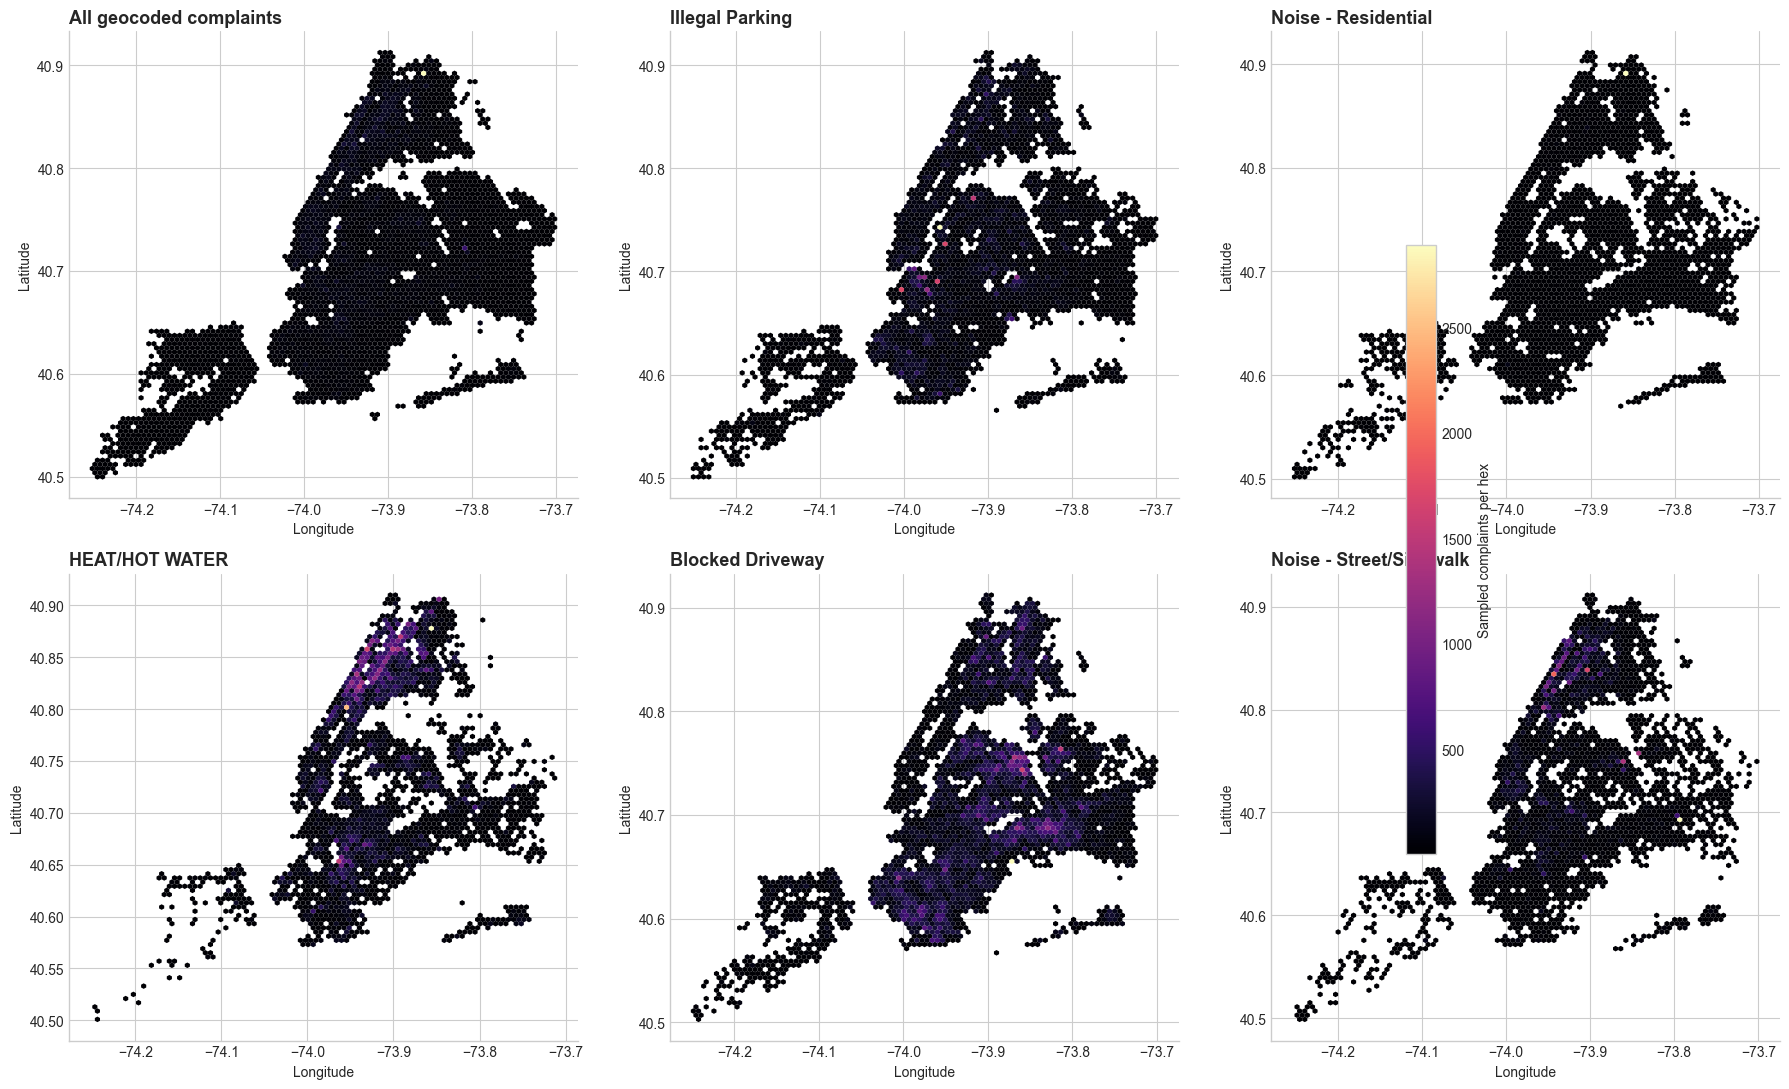

In [6]:
overall_sample = sample_geocoded_rows(df, sample_size=100_000)
top_types = top_complaint_types(df, top_n=5)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
colorbar = plot_hexbin(axes[0], overall_sample, 'All geocoded complaints')

for idx, complaint_type in enumerate(top_types, start=1):
    sample = sample_geocoded_rows(df.loc[df['complaint_type'].eq(complaint_type)], sample_size=40_000)
    plot_hexbin(axes[idx], sample, complaint_type)

fig.colorbar(colorbar, ax=axes.tolist(), shrink=0.72, label='Sampled complaints per hex')
plt.tight_layout()
plt.show()


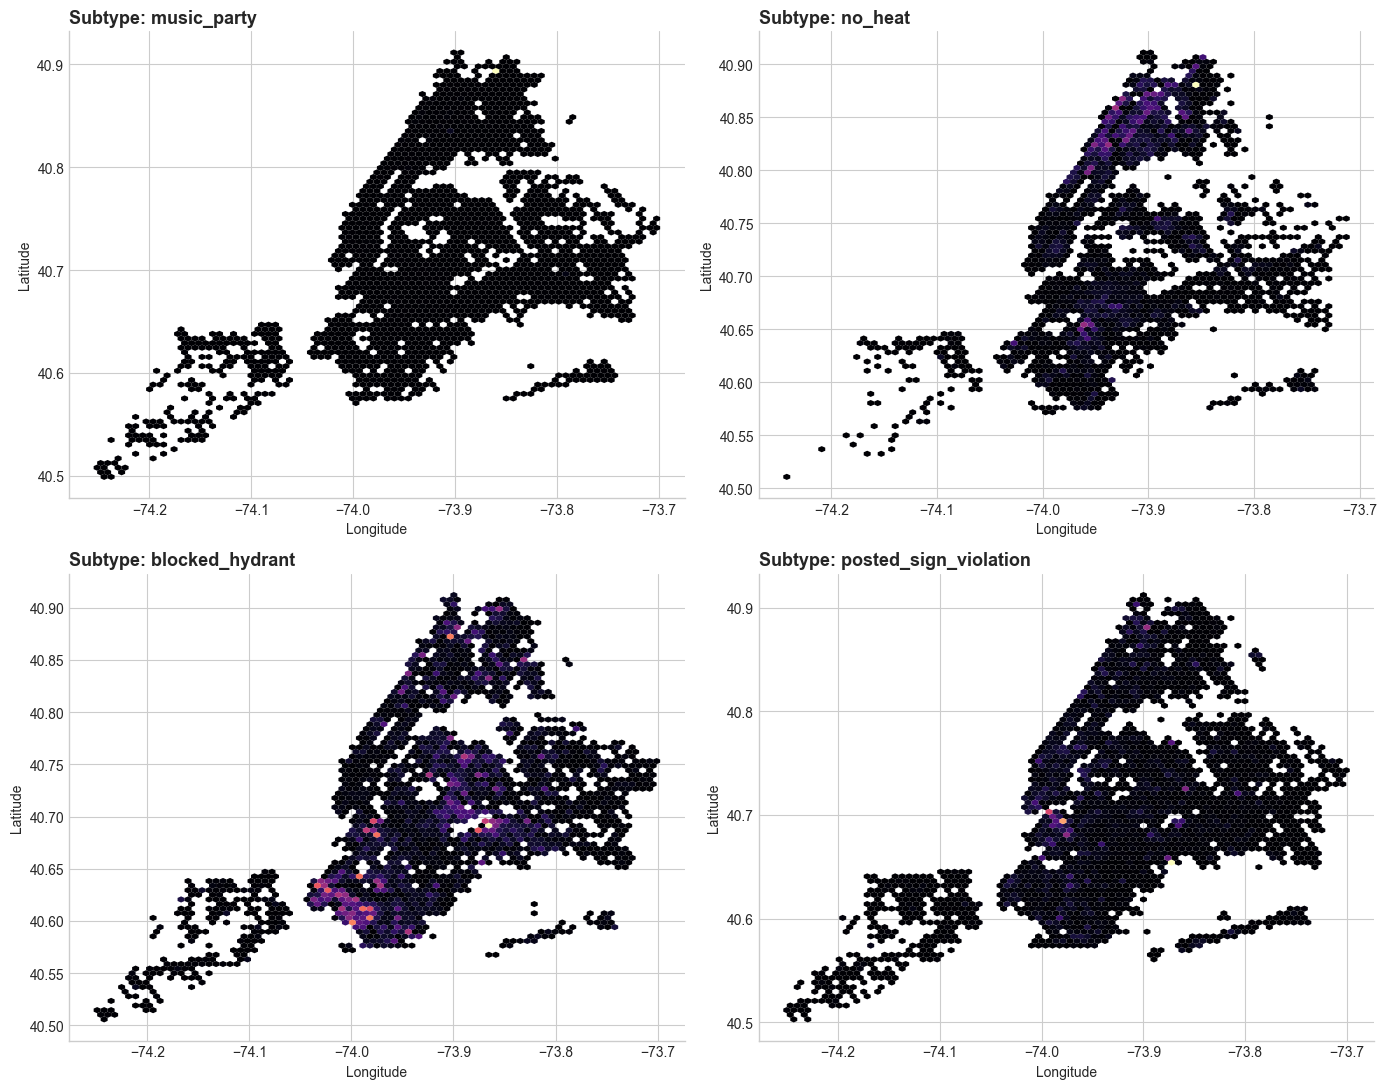

In [7]:
top_subtypes = top_modeled_subtypes(df, top_n=4)
modeled_df = df.loc[df['subtype_modeled_flag'] & df['issue_subtype'].ne('not_modeled')]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
for idx, issue_subtype in enumerate(top_subtypes):
    sample = sample_geocoded_rows(modeled_df.loc[modeled_df['issue_subtype'].eq(issue_subtype)], sample_size=30_000)
    plot_hexbin(axes[idx], sample, f'Subtype: {issue_subtype}', gridsize=80)

plt.tight_layout()
plt.show()


## Counts Versus Per-Capita Burden

These views separate raw volume from resident-normalized burden. The scatter plot makes the difference explicit.


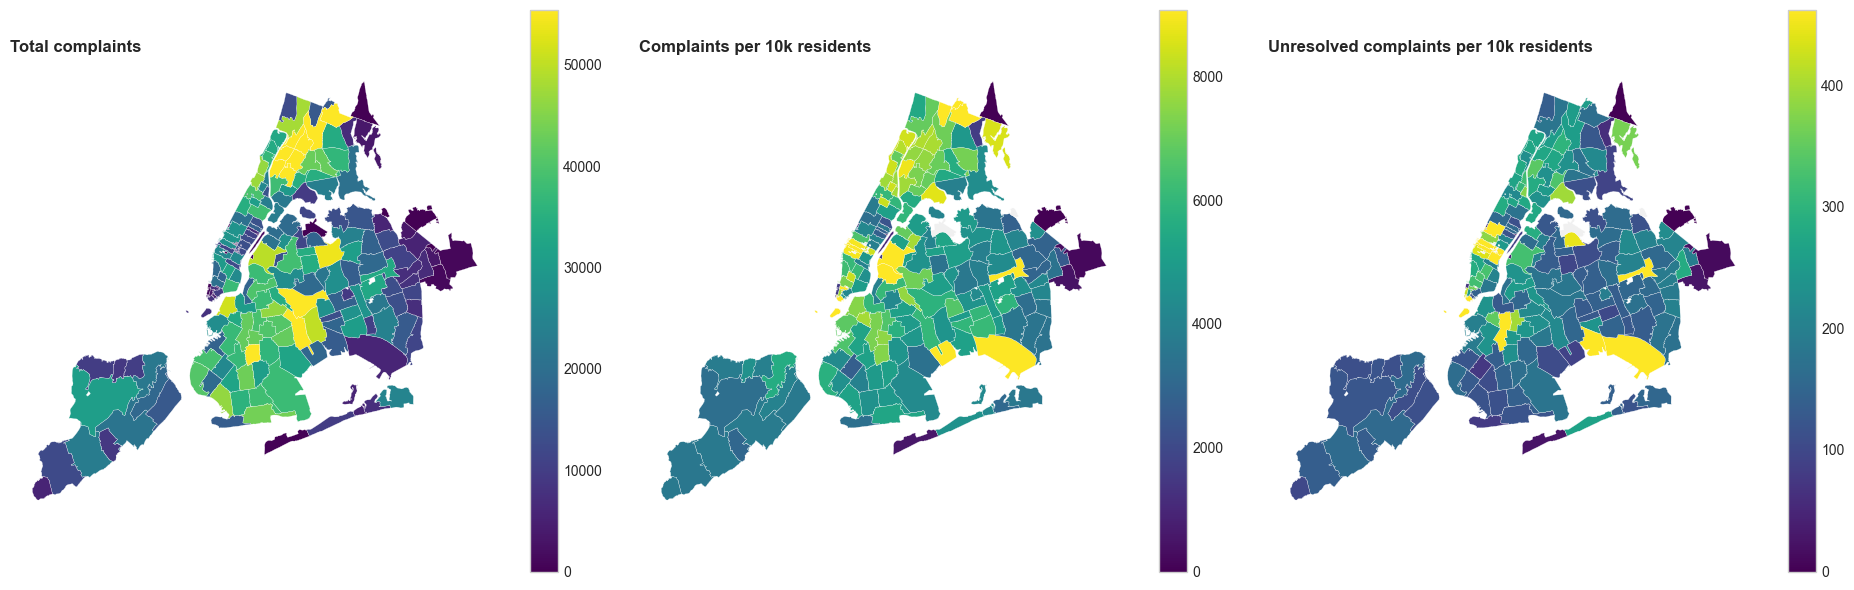

In [8]:
plot_df = zcta_metrics.loc[zcta_metrics['complaints'].gt(0)].copy()
metrics_to_plot = [
    ('complaints', 'Total complaints'),
    ('complaints_per_10k', 'Complaints per 10k residents'),
    ('unresolved_per_10k', 'Unresolved complaints per 10k residents'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (column, title) in zip(axes, metrics_to_plot):
    vmax = plot_df[column].dropna().quantile(0.95)
    plot_df.plot(
        column=column,
        cmap='viridis',
        linewidth=0.18,
        edgecolor='white',
        legend=True,
        ax=ax,
        vmin=0,
        vmax=vmax,
        missing_kwds={'color': '#f0f0f0', 'label': 'Missing'},
    )
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.tight_layout()
plt.show()


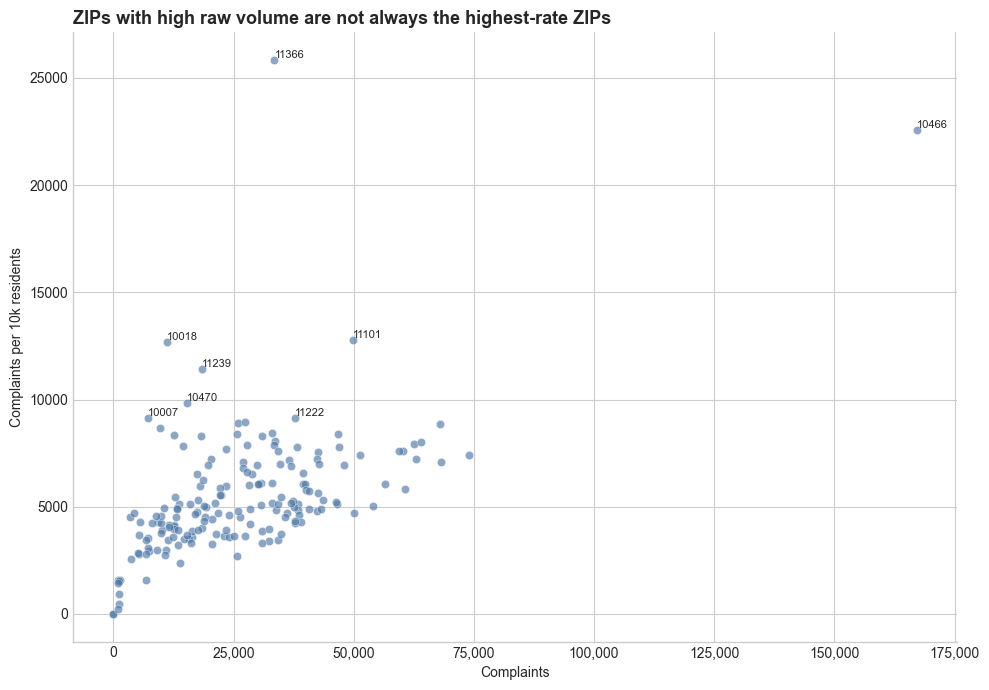

In [9]:
scatter_df = plot_df.loc[plot_df['population'].ge(5000)].copy()
scatter_df['label_flag'] = scatter_df['complaints_per_10k'].rank(ascending=False) <= 8

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(scatter_df['complaints'], scatter_df['complaints_per_10k'], alpha=0.65, color='#4e79a7', edgecolor='white', linewidth=0.4)
for row in scatter_df.loc[scatter_df['label_flag']].itertuples(index=False):
    ax.text(row.complaints, row.complaints_per_10k, row.zcta, fontsize=8, ha='left', va='bottom')
style_axis(ax, 'ZIPs with high raw volume are not always the highest-rate ZIPs', 'Complaints', 'Complaints per 10k residents')
ax.xaxis.set_major_formatter(FuncFormatter(format_int))
plt.tight_layout()
plt.show()


In [10]:
zip_volume_leaders = plot_df[[
    'zcta', 'population', 'complaints', 'unresolved_complaints', 'median_resolution_days', 'p90_resolution_days'
]].sort_values('complaints', ascending=False).head(10)

zip_rate_leaders = plot_df.loc[plot_df['population'].ge(5000), [
    'zcta', 'population', 'complaints_per_10k', 'unresolved_per_10k', 'median_resolution_days', 'p90_resolution_days'
]].sort_values('complaints_per_10k', ascending=False).head(10)

print('Top ZIPs by raw complaint volume')
display(zip_volume_leaders)
print('Top ZIPs by complaint rate among ZIPs with population >= 5,000')
display(zip_rate_leaders)


Top ZIPs by raw complaint volume


,zcta,population,complaints,unresolved_complaints,median_resolution_days,p90_resolution_days
123,10466,74061,167174,1218,0.110475,1.471968
146,11226,100022,74000,2285,1.204884,16.931493
142,10467,96304,68217,2459,0.909062,17.715190
7,10452,76745,67891,2642,1.014583,17.674097
137,10468,79825,63905,2042,0.620139,14.854687
63,10456,86958,62888,2002,0.518032,17.760978
47,10458,78741,62470,2362,1.131950,19.353808
75,11385,103865,60730,1879,0.179456,6.584722
31,10457,79375,60233,2176,0.920718,18.971863
136,10453,78270,59528,2145,1.045868,18.693414


Top ZIPs by complaint rate among ZIPs with population >= 5,000


,zcta,population,complaints_per_10k,unresolved_per_10k,median_resolution_days,p90_resolution_days
24,11366,12967,25831.726691,803.578314,0.017633,0.909345
123,10466,74061,22572.474042,164.459027,0.110475,1.471968
90,11101,39007,12756.171969,323.531674,0.076100,4.224751
206,10018,8764,12701.962574,670.926518,0.419983,25.716507
118,11239,16047,11437.651898,91.605908,0.059259,2.569271
50,10470,15558,9821.956550,253.245918,0.521597,8.869461
62,10007,7802,9155.344783,362.727506,0.030637,5.331694
148,11222,41418,9118.257762,237.819306,0.102361,9.223738
155,10036,30589,8936.545817,558.043741,0.386701,28.766164
129,10001,29079,8908.490663,436.741291,0.078588,12.966215


## Community Board Operational View

Community boards add a neighborhood operations lens even without board polygons. The charts below show where volume concentrates and where closure is slower.


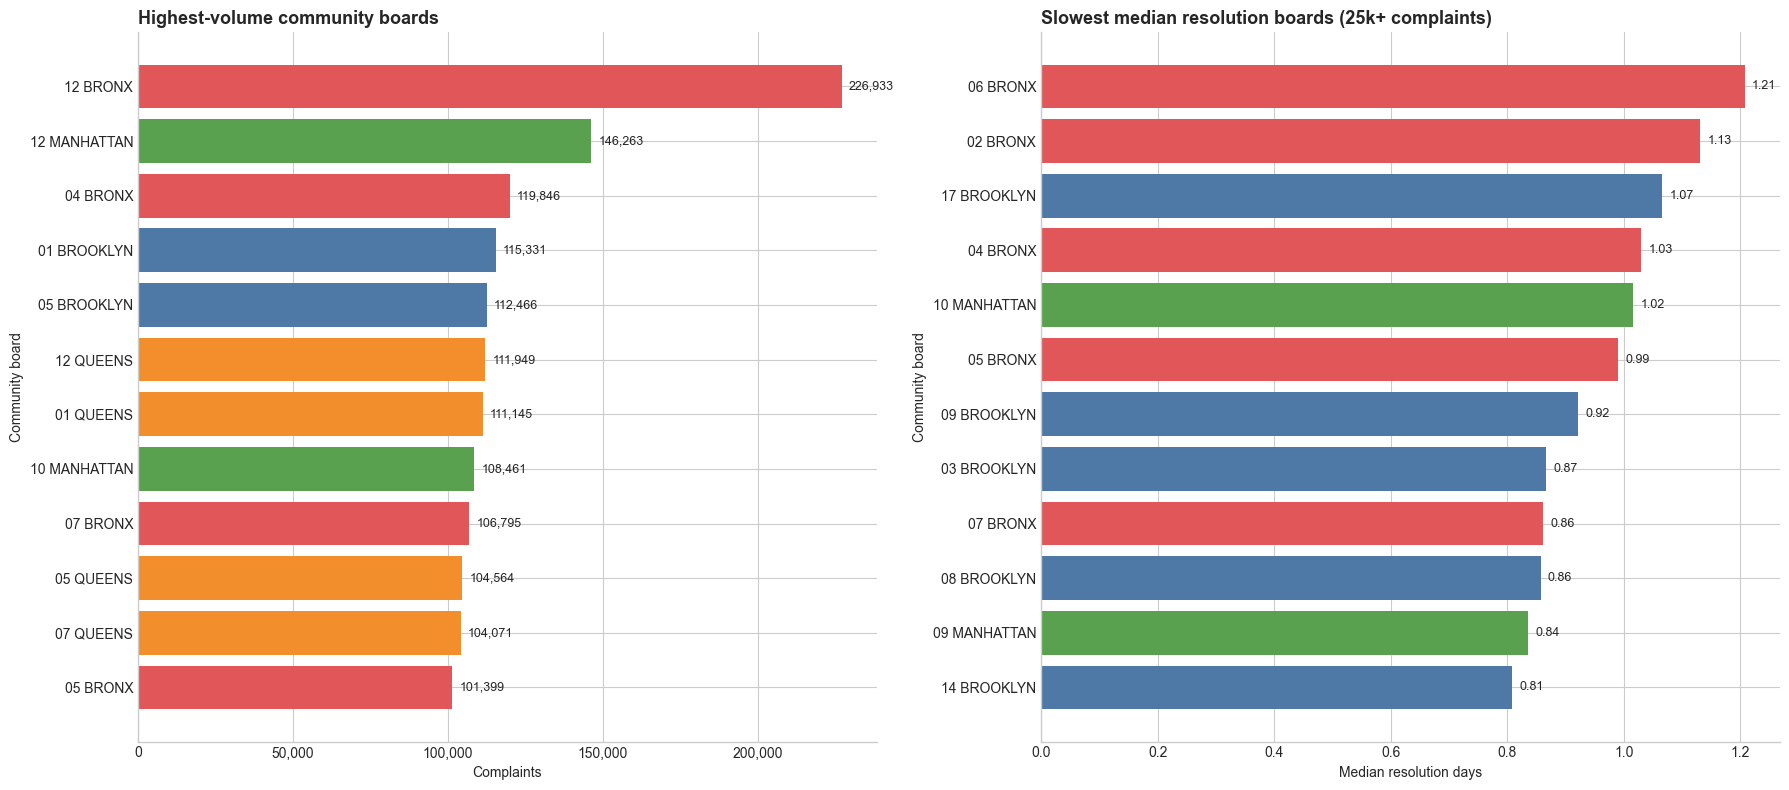

In [11]:
board_plot = community_board_metrics.copy()
high_volume_boards = board_plot.sort_values('complaints', ascending=False).head(12).copy()
slow_boards = board_plot.loc[board_plot['complaints'].ge(25000)].sort_values('median_resolution_days', ascending=False).head(12).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
high_volume_boards = high_volume_boards.sort_values('complaints')
high_volume_colors = [BOROUGH_COLORS.get(b, '#999999') for b in high_volume_boards['community_board_borough']]
axes[0].barh(high_volume_boards['community_board'], high_volume_boards['complaints'], color=high_volume_colors)
style_axis(axes[0], 'Highest-volume community boards', 'Complaints', 'Community board')
axes[0].xaxis.set_major_formatter(FuncFormatter(format_int))
annotate_barh(axes[0], fmt='{:,.0f}')

slow_boards = slow_boards.sort_values('median_resolution_days')
slow_colors = [BOROUGH_COLORS.get(b, '#999999') for b in slow_boards['community_board_borough']]
axes[1].barh(slow_boards['community_board'], slow_boards['median_resolution_days'], color=slow_colors)
style_axis(axes[1], 'Slowest median resolution boards (25k+ complaints)', 'Median resolution days', 'Community board')
annotate_barh(axes[1], fmt='{:.2f}')

plt.tight_layout()
plt.show()


In [12]:
community_board_metrics[[
    'community_board',
    'community_board_borough',
    'complaints',
    'unresolved_share',
    'median_resolution_days',
    'p90_resolution_days',
    'top_complaint_type',
    'top_issue_subtype',
    'mismatch_flag_share',
]].head(20)


,community_board,community_board_borough,complaints,unresolved_share,median_resolution_days,p90_resolution_days,top_complaint_type,top_issue_subtype,mismatch_flag_share
0,12 BRONX,BRONX,226933,0.013541,0.159178,3.456624,Noise - Residential,music_party,0.000004
1,04 BRONX,BRONX,119846,0.037006,1.029711,18.335139,HEAT/HOT WATER,not_modeled,0.0
2,07 BRONX,BRONX,106795,0.035592,0.861968,16.701933,HEAT/HOT WATER,not_modeled,0.0
3,05 BRONX,BRONX,101399,0.036845,0.990220,18.898958,HEAT/HOT WATER,not_modeled,0.0
4,09 BRONX,BRONX,81052,0.032189,0.559595,15.016583,HEAT/HOT WATER,not_modeled,0.0
5,08 BRONX,BRONX,72125,0.024984,0.339734,8.979123,Illegal Parking,not_modeled,0.0
6,03 BRONX,BRONX,71056,0.035226,0.408495,19.650549,Noise - Residential,not_modeled,0.0
7,11 BRONX,BRONX,68224,0.026955,0.381968,12.266111,HEAT/HOT WATER,not_modeled,0.0
8,06 BRONX,BRONX,64916,0.033074,1.207153,19.890069,HEAT/HOT WATER,not_modeled,0.0
9,01 BRONX,BRONX,61502,0.039251,0.770735,21.723997,HEAT/HOT WATER,not_modeled,0.0


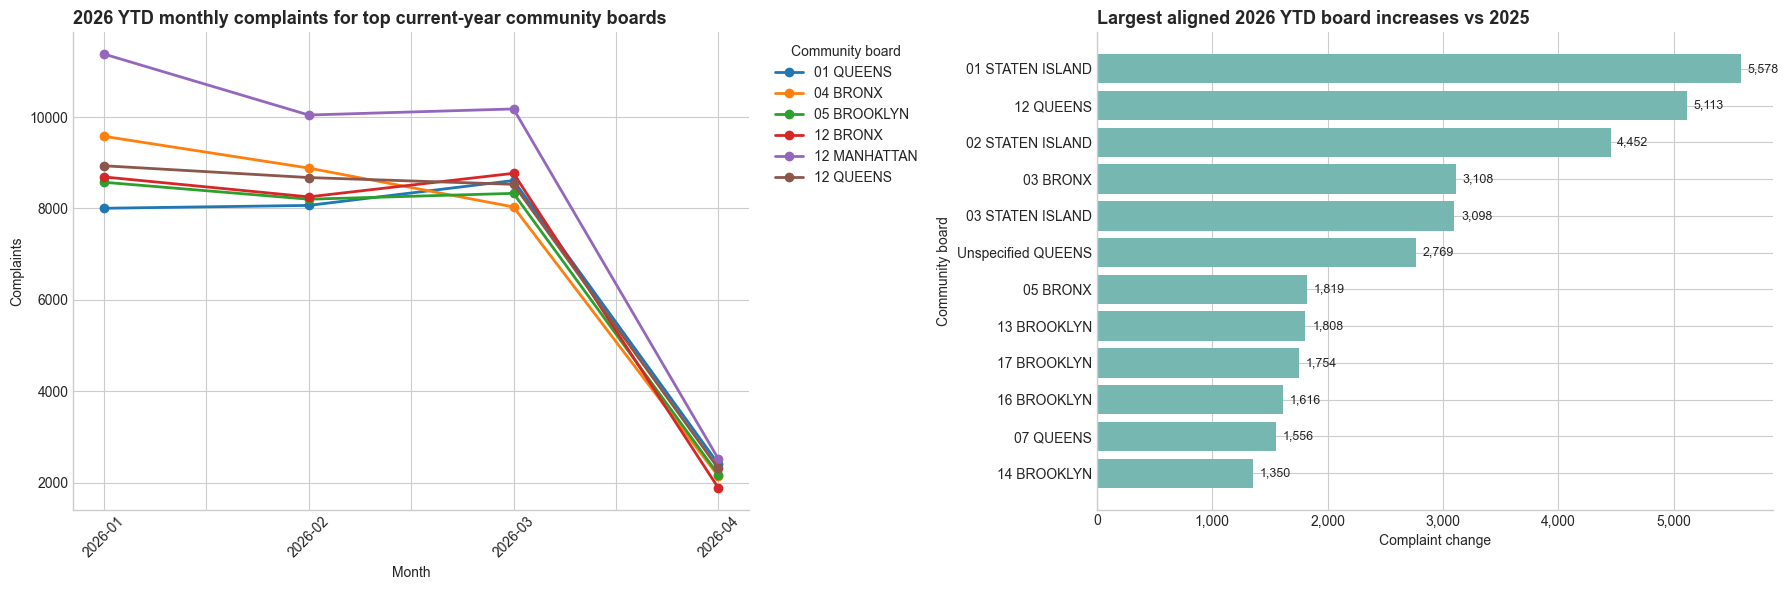

created_year,2025,2026,change_2026_vs_2025
community_board,,,
01 STATEN ISLAND,17275,22853,5578
12 QUEENS,23337,28450,5113
02 STATEN ISLAND,10261,14713,4452
03 BRONX,15463,18571,3108
03 STATEN ISLAND,12466,15564,3098
Unspecified QUEENS,2867,5636,2769
05 BRONX,24069,25888,1819
13 BROOKLYN,8535,10343,1808
17 BROOKLYN,20127,21881,1754


In [13]:
latest_2026_date = df.loc[df['created_year'].eq(2026), 'created_date'].max()
aligned_2025_cutoff = latest_2026_date - pd.DateOffset(years=1)
aligned_board_monthly = community_board_monthly.loc[
    ((community_board_monthly['created_month_start'] >= pd.Timestamp('2025-01-01')) & (community_board_monthly['created_month_start'] <= aligned_2025_cutoff.to_period('M').to_timestamp()))
    | ((community_board_monthly['created_month_start'] >= pd.Timestamp('2026-01-01')) & (community_board_monthly['created_month_start'] <= latest_2026_date.to_period('M').to_timestamp()))
].copy()

board_ytd = (
    aligned_board_monthly.groupby(['created_year', 'community_board'], observed=True)['complaints']
    .sum()
    .reset_index()
)
top_2026_boards = board_ytd.loc[board_ytd['created_year'].eq(2026)].sort_values('complaints', ascending=False).head(6)['community_board']
trend_plot = aligned_board_monthly.loc[aligned_board_monthly['community_board'].isin(top_2026_boards)].copy()
trend_plot['month_label'] = trend_plot['created_month_start'].dt.strftime('%Y-%m')
pivot_2026 = trend_plot.loc[trend_plot['created_year'].eq(2026)].pivot(index='month_label', columns='community_board', values='complaints').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pivot_2026.plot(ax=axes[0], marker='o', linewidth=2)
style_axis(axes[0], '2026 YTD monthly complaints for top current-year community boards', 'Month', 'Complaints')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Community board', bbox_to_anchor=(1.02, 1), loc='upper left')

board_ytd_pivot = board_ytd.pivot(index='community_board', columns='created_year', values='complaints').fillna(0)
board_ytd_pivot['change_2026_vs_2025'] = board_ytd_pivot.get(2026, 0) - board_ytd_pivot.get(2025, 0)
biggest_increases = board_ytd_pivot.sort_values('change_2026_vs_2025', ascending=False).head(12).sort_values('change_2026_vs_2025')
axes[1].barh(biggest_increases.index, biggest_increases['change_2026_vs_2025'], color='#76b7b2')
style_axis(axes[1], 'Largest aligned 2026 YTD board increases vs 2025', 'Complaint change', 'Community board')
axes[1].xaxis.set_major_formatter(FuncFormatter(format_int))
annotate_barh(axes[1], fmt='{:,.0f}')

plt.tight_layout()
plt.show()

board_ytd_pivot.sort_values('change_2026_vs_2025', ascending=False).head(15)


## Persistent Hotspot Zones

A fixed grid highlights zones that repeatedly land in the monthly top decile of complaint volume. This is more stable than a single density surface.


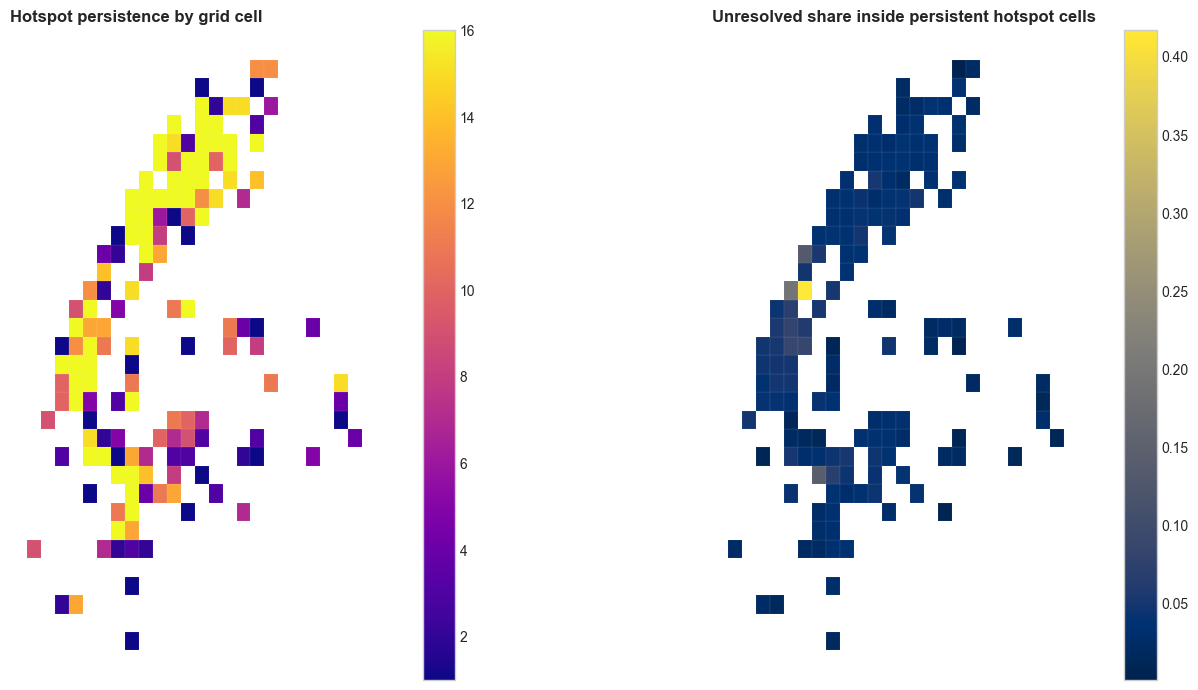

In [14]:
persistent_plot = grid_persistence.loc[grid_persistence['hotspot_months'].gt(0)].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
persistent_plot.plot(column='hotspot_months', cmap='plasma', legend=True, linewidth=0.05, edgecolor='white', ax=axes[0])
axes[0].set_title('Hotspot persistence by grid cell', loc='left', fontsize=12, fontweight='bold')
axes[0].set_axis_off()
persistent_plot.plot(column='unresolved_share', cmap='cividis', legend=True, linewidth=0.05, edgecolor='white', ax=axes[1])
axes[1].set_title('Unresolved share inside persistent hotspot cells', loc='left', fontsize=12, fontweight='bold')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()


In [15]:
persistent_plot[[
    'grid_id',
    'total_complaints',
    'total_unresolved_complaints',
    'hotspot_months',
    'active_months',
    'hotspot_month_share',
    'unresolved_share',
]].sort_values(['hotspot_months', 'total_complaints'], ascending=[False, False]).head(15)


,grid_id,total_complaints,total_unresolved_complaints,hotspot_months,active_months,hotspot_month_share,unresolved_share
323,33:33,33760,1254,16,16,1.0,0.037145
384,35:34,32262,1612,16,16,1.0,0.049966
454,37:36,31828,1272,16,16,1.0,0.039965
387,35:37,31735,1066,16,16,1.0,0.033591
417,36:34,30533,974,16,16,1.0,0.0319
212,29:23,30009,1454,16,16,1.0,0.048452
324,33:34,29120,943,16,16,1.0,0.032383
490,38:37,28352,1083,16,16,1.0,0.038198
418,36:35,27672,976,16,16,1.0,0.03527
355,34:36,27052,840,16,16,1.0,0.031051


## Hotspot Summaries By Category

These tables tie the spatial layer back to both the official complaint labels and the Phase 4 issue-subtype taxonomy.


In [16]:
complaint_hotspots = summarize_hotspot_grids(df, 'complaint_type', top_n_categories=6, top_n_grids=3)
subtype_hotspots = summarize_hotspot_grids(
    df.loc[df['subtype_modeled_flag'] & df['issue_subtype'].ne('not_modeled')],
    'issue_subtype',
    top_n_categories=6,
    top_n_grids=3,
)

print('Top grid hotspots by complaint type')
display(complaint_hotspots)
print('Top grid hotspots by modeled subtype')
display(subtype_hotspots)


Top grid hotspots by complaint type


,complaint_type,grid_id,complaints,boroughs
0,Blocked Driveway,41:26,2396,QUEENS
1,Blocked Driveway,42:25,1997,QUEENS
2,Blocked Driveway,45:19,1867,QUEENS
3,HEAT/HOT WATER,33:33,7745,MANHATTAN
4,HEAT/HOT WATER,34:36,7190,MANHATTAN
5,HEAT/HOT WATER,38:36,7020,BRONX
6,Illegal Parking,32:25,13468,QUEENS
7,Illegal Parking,36:27,8845,QUEENS
8,Illegal Parking,32:23,8405,BROOKLYN
9,Noise - Residential,41:40,127427,BRONX


Top grid hotspots by modeled subtype


,issue_subtype,grid_id,complaints,boroughs
0,banging_pounding,28:11,5360,BROOKLYN
1,banging_pounding,29:20,3361,BROOKLYN
2,banging_pounding,34:33,2884,"BRONX, MANHATTAN"
3,blocked_hydrant,41:20,3632,"BROOKLYN, QUEENS"
4,blocked_hydrant,25:14,2572,BROOKLYN
5,blocked_hydrant,29:12,2122,BROOKLYN
6,music_party,41:40,127262,BRONX
7,music_party,37:34,8617,BRONX
8,music_party,48:20,5647,QUEENS
9,no_access,41:26,1948,QUEENS


## Findings

Main spatial takeaways from the current Phase 5 outputs.


In [17]:
top_count_zip = plot_df.sort_values('complaints', ascending=False).iloc[0]
top_rate_zip = plot_df.loc[plot_df['population'].ge(5000)].sort_values('complaints_per_10k', ascending=False).iloc[0]
top_board = community_board_metrics.sort_values('complaints', ascending=False).iloc[0]
slow_board = community_board_metrics.loc[community_board_metrics['complaints'].ge(25000)].sort_values('median_resolution_days', ascending=False).iloc[0]
top_persistent_grid = persistent_plot.sort_values(['hotspot_months', 'total_complaints'], ascending=[False, False]).iloc[0]
top_type = df['complaint_type'].value_counts().idxmax()
top_subtype = df.loc[df['subtype_modeled_flag'], 'issue_subtype'].value_counts().idxmax()

findings = [
    f"- {df['valid_coordinate_flag'].mean():.1%} of scoped complaints are geocoded well enough for hotspot mapping.",
    f"- ZIP {top_count_zip['zcta']} leads raw complaint volume with {int(top_count_zip['complaints']):,} complaints.",
    f"- Among ZIPs with population of at least 5,000, ZIP {top_rate_zip['zcta']} has the highest complaint rate at {top_rate_zip['complaints_per_10k']:.1f} per 10k residents.",
    f"- Community board {top_board['community_board']} has the highest complaint volume at {int(top_board['complaints']):,}.",
    f"- Among boards with at least 25,000 complaints, {slow_board['community_board']} has the slowest median resolution time at {slow_board['median_resolution_days']:.2f} days.",
    f"- The most persistent hotspot grid cell appears in {int(top_persistent_grid['hotspot_months'])} monthly top-decile windows.",
    f"- The citywide leader remains {top_type}, while the most common modeled subtype is {top_subtype}.",
]
print('\n'.join(findings))


- 98.3% of scoped complaints are geocoded well enough for hotspot mapping.
- ZIP 10466 leads raw complaint volume with 167,174 complaints.
- Among ZIPs with population of at least 5,000, ZIP 11366 has the highest complaint rate at 25831.7 per 10k residents.
- Community board 12 BRONX has the highest complaint volume at 226,933.
- Among boards with at least 25,000 complaints, 06 BRONX has the slowest median resolution time at 1.21 days.
- The most persistent hotspot grid cell appears in 16 monthly top-decile windows.
- The citywide leader remains Illegal Parking, while the most common modeled subtype is music_party.


## So What

For a portfolio or stakeholder readout, the practical message is simple: the project now shows not just what residents report, but where pressure concentrates, where burden looks disproportionately high, and which zones stay operationally hot over time. That makes the Phase 5 layer usable for prioritization, neighborhood comparison, and follow-on response-time analysis in Phase 6.


In [18]:
so_what = pd.DataFrame({
    'question': [
        'Where is complaint pressure concentrated?',
        'Where does burden look highest after normalization?',
        'Which neighborhood operating areas stand out?',
        'Where are recurring hotspots strongest?',
    ],
    'phase_5_answer': [
        f"Point-density maps and hotspot grids show the heaviest citywide concentration, led by {top_type}.",
        f"ZIP-level rates show that {top_rate_zip['zcta']} looks most burdened among sufficiently populated ZIPs.",
        f"Community board {top_board['community_board']} leads volume, while {slow_board['community_board']} is slowest on median resolution among larger boards.",
        f"The top hotspot cell persists across {int(top_persistent_grid['hotspot_months'])} monthly top-decile windows, which points to recurring rather than one-off pressure.",
    ],
})
so_what


,question,phase_5_answer
0,Where is complaint pressure concentrated?,Point-density maps and hotspot grids show the ...
1,Where does burden look highest after normaliza...,ZIP-level rates show that 11366 looks most bur...
2,Which neighborhood operating areas stand out?,"Community board 12 BRONX leads volume, while 0..."
3,Where are recurring hotspots strongest?,The top hotspot cell persists across 16 monthl...
